# Resampled TEASAR skeleton statistics: 2,209 cells, >5-site components

Use the exact 2,209-cell cohort from the original notebook, with the registered
TEASAR skeletons resampled to a maximum edge spacing of approximately 111 nm
(short original edges remain; this is not an exactly uniform grid).

Presynaptic points are mapped directly to the nearest **resampled node** after
the same 5 µm soma cut. Keep connected components with **more than five unique
presynaptic IDs mapped within 2 µm**. All edges in each qualifying component
are retained; embeddings are not required and this is not an axon classifier.

The summary, pooled fits, cell-type distributions, and upstream branch/site
plots all use this component filter. Upstream analyses additionally require a
tree with exactly one soma-cut boundary root. Derived statistics are cached.
The database manifest records the exact resampled source for every cell.

In [1]:
get_ipython().run_line_magic("matplotlib", "inline")
import os
os.environ['NUMPY_MADVISE_HUGEPAGE'] = '0'
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import importlib

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'gnn').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from analysis.presynaptic.new_skeletons_native import skeleton_stats
importlib.reload(skeleton_stats)
PRESYNAPTIC_DATABASE = skeleton_stats.PRESYNAPTIC_DATABASE
print(f"Stats helper: {skeleton_stats.__file__}")

from analysis.presynaptic.new_skeletons_native.skeleton_stats import (
    GMM_COMPONENTS, PLOT_PERCENTILES, load_presynaptic_lengths, parameter_table,
    plot_distribution_and_gmm, streaming_quantiles, summarize,
)
N_COMPONENTS = 3
presynaptic_lengths = load_presynaptic_lengths()
print(f'Presynaptic database: {PRESYNAPTIC_DATABASE}')
print(f'Retained resampled TEASAR edges: {len(presynaptic_lengths):,}')


Stats helper: /orcd/home/002/jcbliao/rotation/segclr/gnn_classifier/analysis/presynaptic/new_skeletons_native/skeleton_stats.py


Component cache: 1/2,209 cells


Component cache: 100/2,209 cells


Component cache: 200/2,209 cells


Component cache: 300/2,209 cells


...

Component cache: 2,100/2,209 cells


Component cache: 2,200/2,209 cells


Component cache: 2,209/2,209 cells


>5-site components: 269,133,542 / 308,397,752 edges; 2,209 cells (persistent cache)


Presynaptic database: /orcd/scratch/orcd/013/jcbliao/presynaptic_axons/resampled_teasar_2209/native
Retained resampled TEASAR edges: 269,133,542


## Untrimmed summary of retained components

Summary covers all positive finite edges in components with >5 sites. The first calculation scans the retained array several times; subsequent calls load the cached summary. `.round(2)` and `display` only operate on the small summary table. Percentile trimming applies only to plots and fits.


In [2]:
summary = summarize(presynaptic_lengths)
display(summary.round(2))

,edges,mean_nm,std_nm,p1_nm,p5_nm,p25_nm,p50_nm,p75_nm,p95_nm,p99_nm
Presynaptic-derived TEASAR,269133542,83.22,17.25,55.81,57.1,65.71,85.4,98.27,108.4,110.59


## Edge-length probability mass and Gaussian mixtures

The logarithmic plot uses geometrically spaced edge-length bins and a Gaussian mixture fitted to `log10(edge length)`. The linear plot uses equal-width nanometer bins and a Gaussian mixture fitted directly in nanometers. Component curves include their mixture weights; the black curve is their sum. Fits still use the central 99% population; the outermost 1% is excluded from fitting as well as display. Each observed PMF and fitted mixture sums to one over the displayed range.

Displayed range: 55.65–110.83 nm (0.5th–99.5th percentiles)
Building histogram and mixture fit (cached after this run)


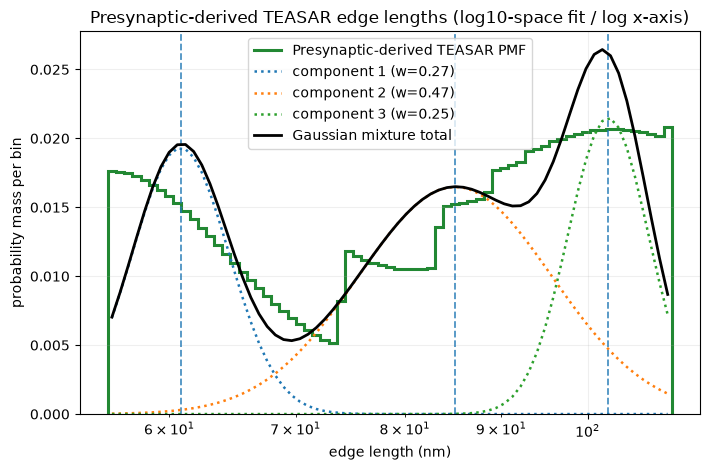

In [3]:
bounds = streaming_quantiles(presynaptic_lengths, PLOT_PERCENTILES, log_bins=True)
print(f'Displayed range: {bounds[0]:,.2f}–{bounds[1]:,.2f} nm '      f'({PLOT_PERCENTILES[0]}th–{PLOT_PERCENTILES[1]}th percentiles)')

log_figure, log_model = plot_distribution_and_gmm(
    presynaptic_lengths, bounds, log_space=True, n_components=N_COMPONENTS,
    family="Gaussian", compare_gaussian=False
)
plt.close(log_figure)  # Display once via the final expression.
log_figure


Building histogram and mixture fit (cached after this run)


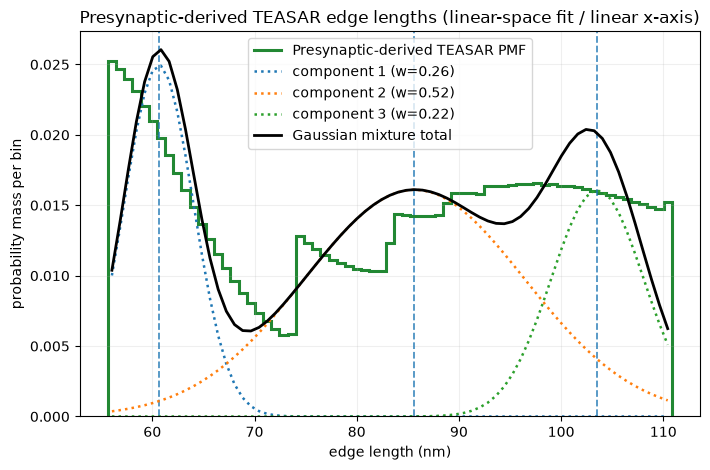

In [4]:
linear_figure, linear_model = plot_distribution_and_gmm(
    presynaptic_lengths, bounds, log_space=False, n_components=N_COMPONENTS,
    family="Gaussian", compare_gaussian=False
)
plt.close(linear_figure)  # Display once via the final expression.
linear_figure


## Mixture parameters

For the log10 fit, `location_fit_units` and `scale_fit_units` are in log10(nm); `component_center_nm` transforms the component location back to nanometers. Linear-fit values are directly in nanometers. Gaussian locations are component means and scales are standard deviations in the fitted space. The log-space fit corresponds to a mixture of lognormal distributions in nanometers. The component count is explicitly set by `N_COMPONENTS = 3`; it is not selected automatically.

In [5]:
display(parameter_table(log_model, linear_model).round(4))

,fit_space,component,weight,family,location_fit_units,scale_fit_units,component_center_nm,iterations
0,log10,1,0.2745,Gaussian,1.7840,0.0255,60.8192,168
1,log10,2,0.4705,Gaussian,1.9297,0.0514,85.0505,168
2,log10,3,0.2549,Gaussian,2.0109,0.0213,102.5467,168
3,linear,1,0.2557,Gaussian,60.6296,3.3840,60.6296,166
4,linear,2,0.5241,Gaussian,85.6524,10.7730,85.6524,166
5,linear,3,0.2203,Gaussian,103.5519,4.5310,103.5519,166


## Edge-length distributions by cell type

These empirical distributions use the same presynaptic-derived skeleton edges, grouped by `cell_type` in the native database manifest (copied from `data/manifest.json`). Each type is normalized separately within the same pooled percentile bounds used above. Edges are pooled across cells (so larger skeletons contribute more edges), with each edge counted once per cell. Each cell type has its own panel in a K × 5 grid, using identical linear bins and shared x- and y-axis limits, with no mixture fits. Missing labels appear as `Unlabeled`; the table reports cell and edge counts, including types with no edges inside the displayed range.


,cell_type,cells,positive_finite_edges,displayed_edges
0,AltBasket,34,4237116,4203331
1,AltDTC,9,766423,760612
2,DTC,16,2507317,2489800
3,ITC,71,5839972,5785886
4,ITCperi,18,1273668,1263382
5,L1,13,1242500,1225916
6,L2IT,346,37321344,36895636
7,L3IT,245,26634900,26383574
8,L4IT,546,54085777,53366689
9,L5ET,58,6809188,6758868


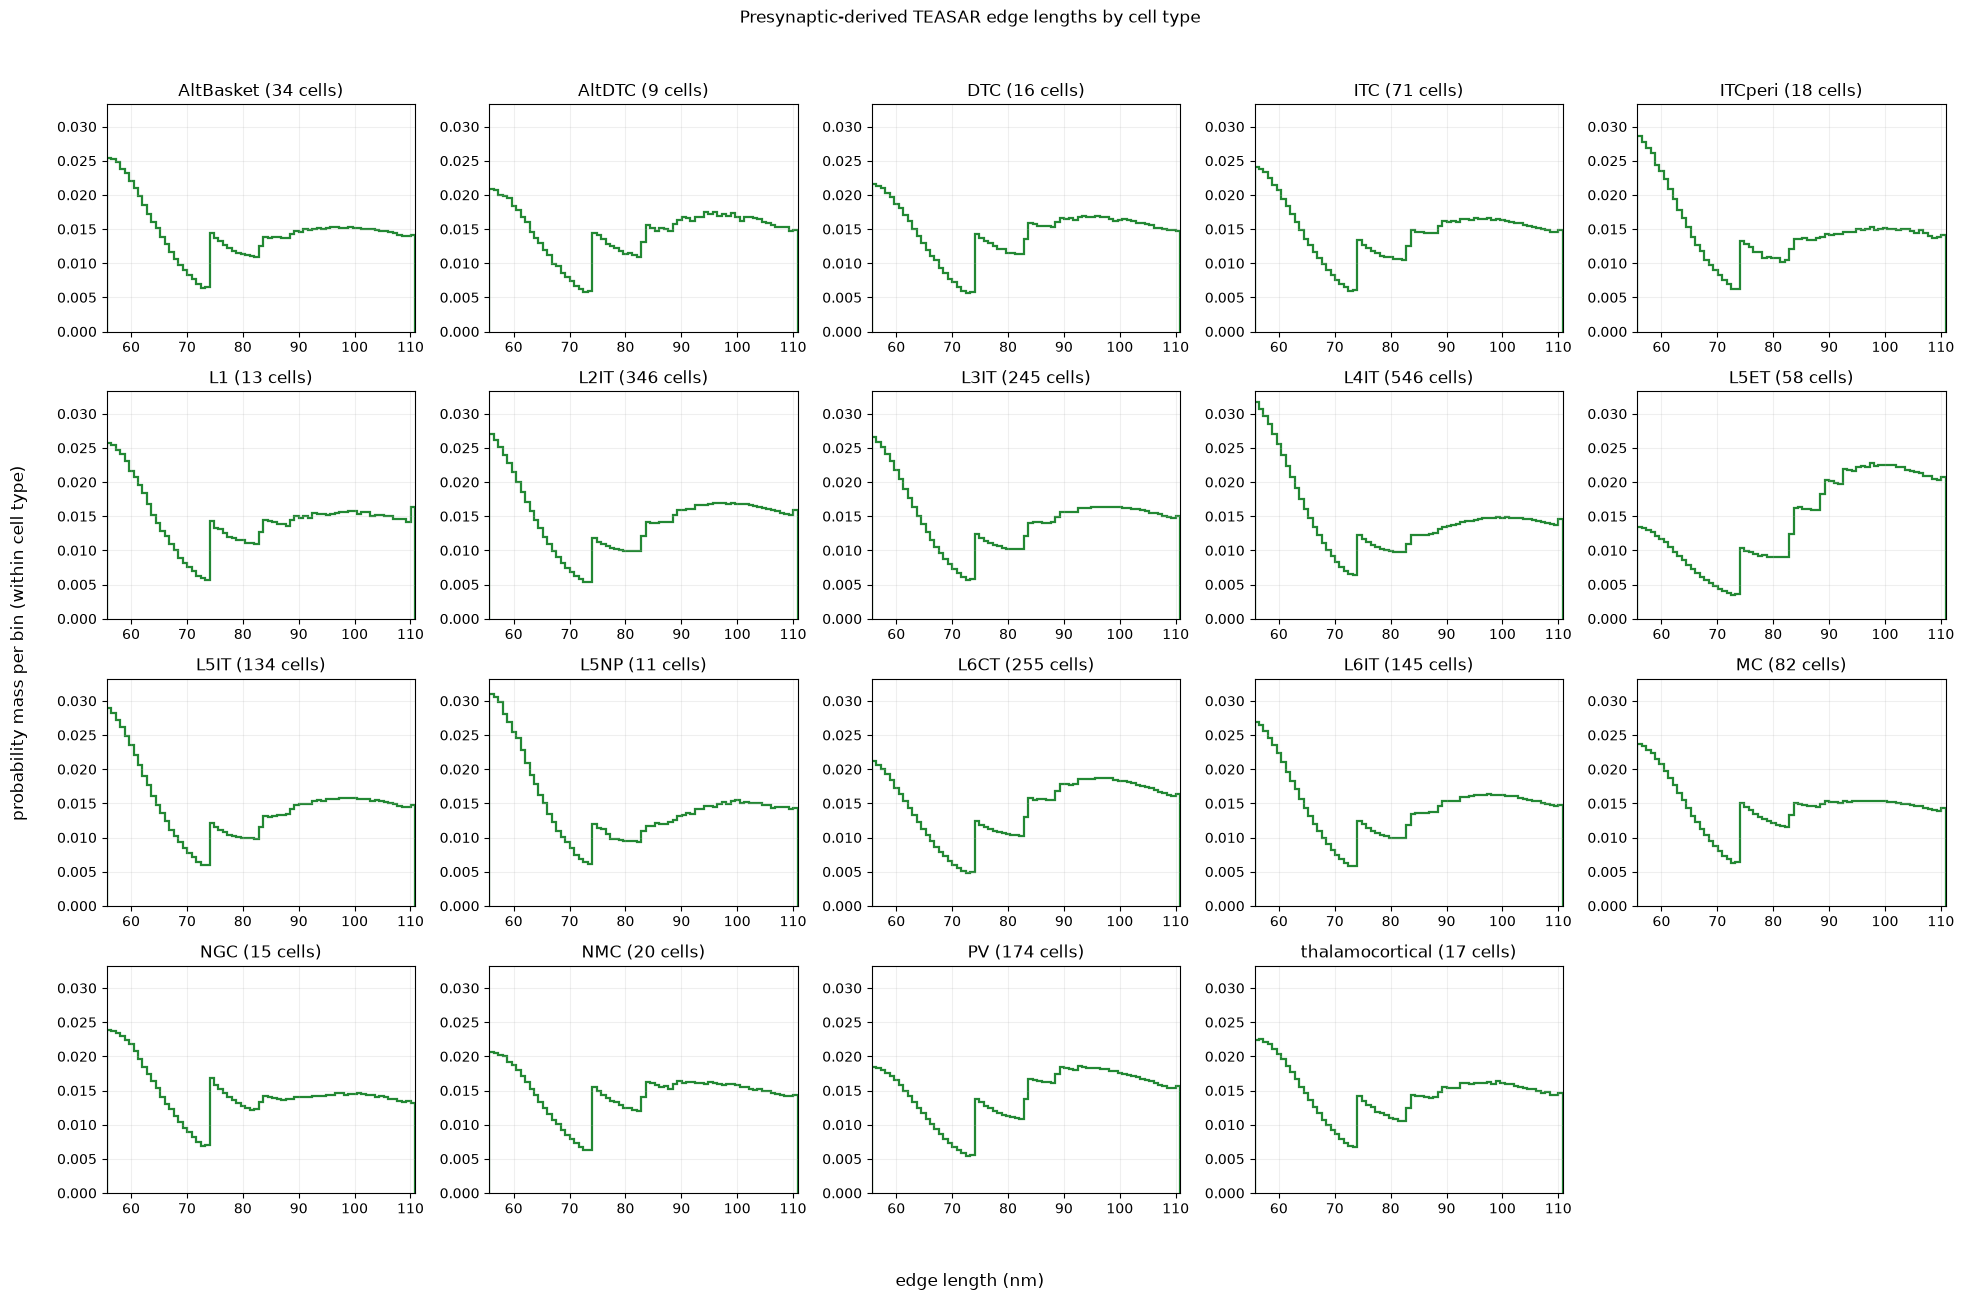

In [6]:
# Reload the helper so this section also works in an existing kernel.
importlib.reload(skeleton_stats)
cell_type_figure, cell_type_counts = skeleton_stats.plot_distributions_by_cell_type(
    bounds, database=PRESYNAPTIC_DATABASE, manifest=skeleton_stats.MANIFEST
)
display(cell_type_counts)
plt.close(cell_type_figure)  # Display once via the final expression.
cell_type_figure


## Edge length versus upstream branch points and synapses

Trees are oriented away from the surviving cut-adjacent root, recovered by reconstructing and verifying the soma cut against the original skeleton. For each edge, counts cover the **path from the root through the edge's proximal (upstream) endpoint**, including that endpoint and excluding the distal endpoint:

- **Upstream branch points:** non-root nodes with two or more children along that path. The cut root is branch point zero, so edges leaving it have count 0 even if it branches. An edge entering the first non-root branch point has count 0; edges leaving that branch point have count 1.
- **Upstream synapses:** unique presynaptic-site IDs mapped to nodes along that path, including sites on the cut root. Sites in sibling branches and at the distal endpoint are excluded. We use the database's `new_nearest_observed_node` mappings accepted by `new_within_2um`, without requiring `new_valid_k_window`. Here `new_nearest_observed_node` is a compatibility field naming the nearest resampled node; no embedding is required. Distinct sites on the same node all count.

Components with no cut-adjacent root, multiple candidate roots, or cycles are excluded and reported. Unmatched sites and sites on excluded components are also reported. Each eligible edge contributes once; counts do not include erased soma-region nodes.

Both metrics are computed in one parallel pass with compiled graph orientation and path summation. Exact histograms are stored sparsely. Plots use linear axes, the same edge-length bounds as above, and at most 200 equal-width x bins (the count width is labeled). No edges are sampled. Color shows edge count on a logarithmic scale. Each metric has a pooled plot and a K × 5 cell-type grid with shared bounds and color scale. Change `UPSTREAM_WORKERS` to control concurrency; replotting `upstream_length_data` does not repeat collection.


In [7]:
import os
os.environ['NUMPY_MADVISE_HUGEPAGE'] = '0'
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import importlib

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'gnn').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from analysis.presynaptic.new_skeletons_native import skeleton_stats
importlib.reload(skeleton_stats)
PRESYNAPTIC_DATABASE = skeleton_stats.PRESYNAPTIC_DATABASE
print(f"Stats helper: {skeleton_stats.__file__}")

# This section can also run independently.
presynaptic_lengths = skeleton_stats.load_presynaptic_lengths()
bounds = skeleton_stats.streaming_quantiles(presynaptic_lengths, skeleton_stats.PLOT_PERCENTILES)
UPSTREAM_WORKERS = None
upstream_length_data = skeleton_stats.collect_upstream_length_histograms(
    bounds, manifest=skeleton_stats.MANIFEST, workers=UPSTREAM_WORKERS
)
upstream_diagnostics = upstream_length_data["diagnostics"]
display(upstream_diagnostics.groupby("cell_type").sum(numeric_only=True))


Stats helper: /orcd/home/002/jcbliao/rotation/segclr/gnn_classifier/analysis/presynaptic/new_skeletons_native/skeleton_stats.py
>5-site components: 269,133,542 / 308,397,752 edges; 2,209 cells (persistent cache)


Upstream counts: 2,209 cells, 4 worker(s)


Upstream counts: 1/2,209 cells (2.5s, 0.4 cells/s)


Upstream counts: 100/2,209 cells (5.7s, 17.6 cells/s)


Upstream counts: 200/2,209 cells (9.1s, 22.0 cells/s)


...

Upstream counts: 2,000/2,209 cells (65.3s, 30.6 cells/s)


Upstream counts: 2,100/2,209 cells (68.3s, 30.7 cells/s)


Upstream counts: 2,200/2,209 cells (71.0s, 31.0 cells/s)


Upstream counts: 2,209/2,209 cells (71.4s, 31.0 cells/s)


,components,rooted_tree_components,no_boundary_root_components,multiple_boundary_root_components,non_tree_components,excluded_edges,included_edges,synapses_in_rooted_trees,synapses_in_excluded_components,source_presynaptic_site_rows,source_unmatched_presynaptic_site_rows,source_duplicate_matched_site_rows,source_matched_unique_presynaptic_sites,matched_unique_presynaptic_sites,positive_finite_rooted_edges,displayed_edges
cell_type,,,,,,,,,,,,,,,,
AltBasket,96,95,0,1,0,63367,4173749,44401,521,45861,690,0,45171,44922,4173749,4140465
AltDTC,29,28,0,1,0,72859,693564,4581,687,5577,284,0,5293,5268,693564,688325
DTC,64,63,0,1,0,31163,2476154,29915,107,31347,1197,0,30150,30022,2476154,2458789
ITC,131,126,0,5,0,101146,5738826,42385,277,45737,2882,0,42855,42662,5738826,5685361
ITCperi,31,28,0,3,0,142484,1131184,10809,1190,12772,708,0,12064,11999,1131184,1122109
L1,26,25,0,1,0,28468,1214032,18075,562,19226,521,0,18705,18637,1214032,1197627
L2IT,921,871,0,50,0,2602198,34719146,139792,8403,158205,7094,0,151111,148195,34719146,34326430
L3IT,607,590,0,17,0,871387,25763513,134438,4378,148598,7543,0,141055,138816,25763513,25518632
L4IT,1144,1089,0,55,0,2814267,51271510,332650,17260,373910,20051,0,353859,349910,51271510,50583550


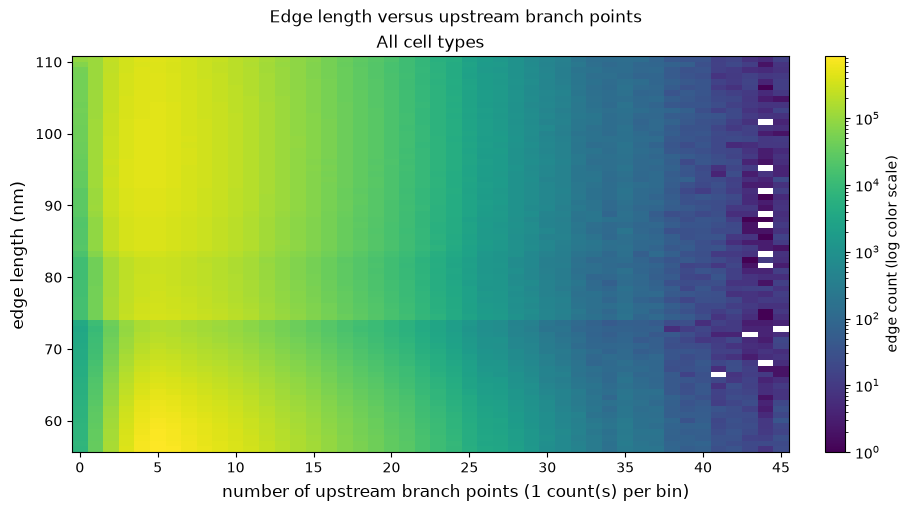

In [8]:
upstream_branch_figure = skeleton_stats.plot_edge_length_by_upstream_count(
    upstream_length_data, metric="branches"
)
plt.close(upstream_branch_figure)  # Display once via the final expression.
upstream_branch_figure


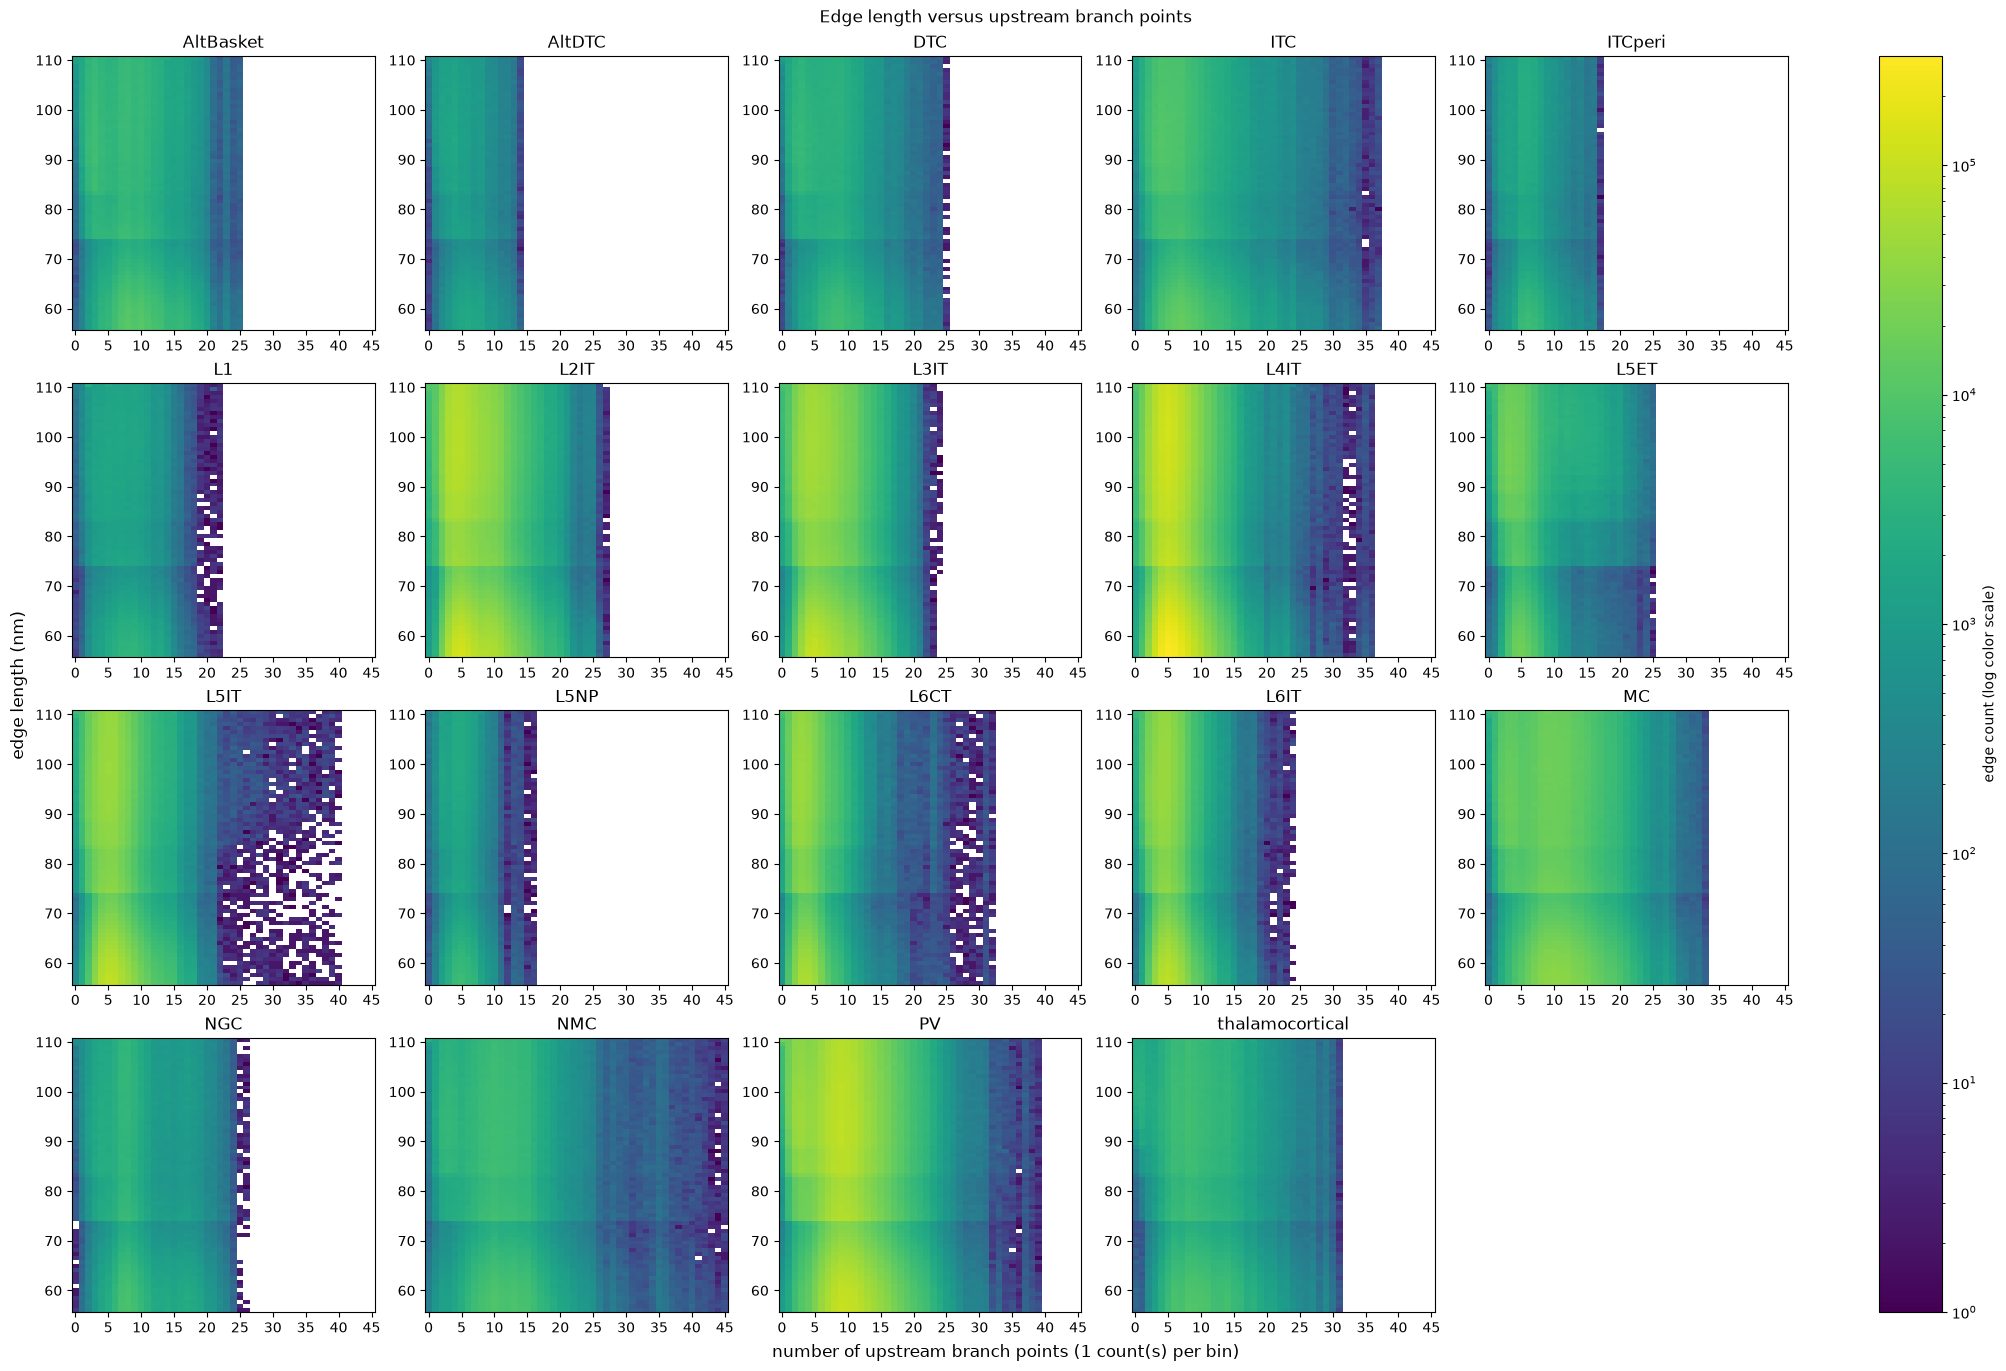

In [9]:
upstream_branch_cell_type_figure = skeleton_stats.plot_edge_length_by_upstream_count(
    upstream_length_data, metric="branches", by_cell_type=True
)
plt.close(upstream_branch_cell_type_figure)  # Display once via the final expression.
upstream_branch_cell_type_figure


## Edge length versus upstream presynaptic sites


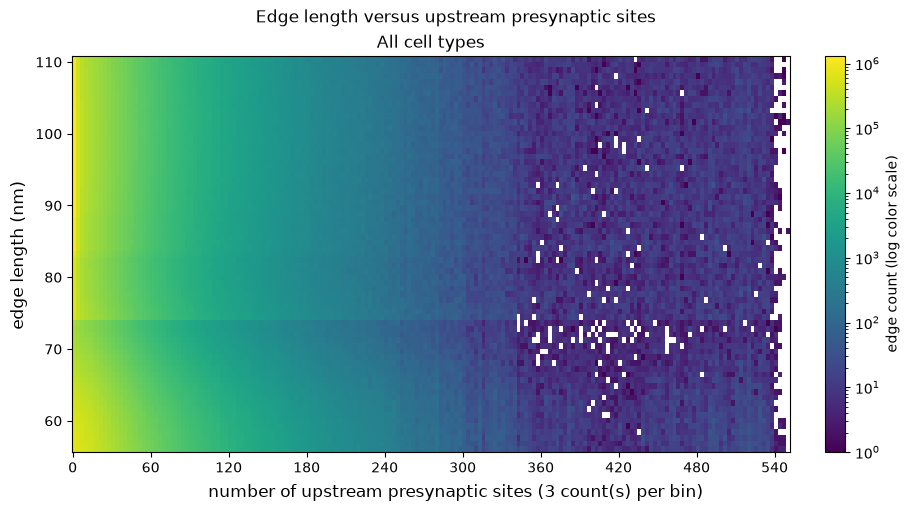

In [10]:
upstream_synapse_figure = skeleton_stats.plot_edge_length_by_upstream_count(
    upstream_length_data, metric="synapses"
)
plt.close(upstream_synapse_figure)  # Display once via the final expression.
upstream_synapse_figure


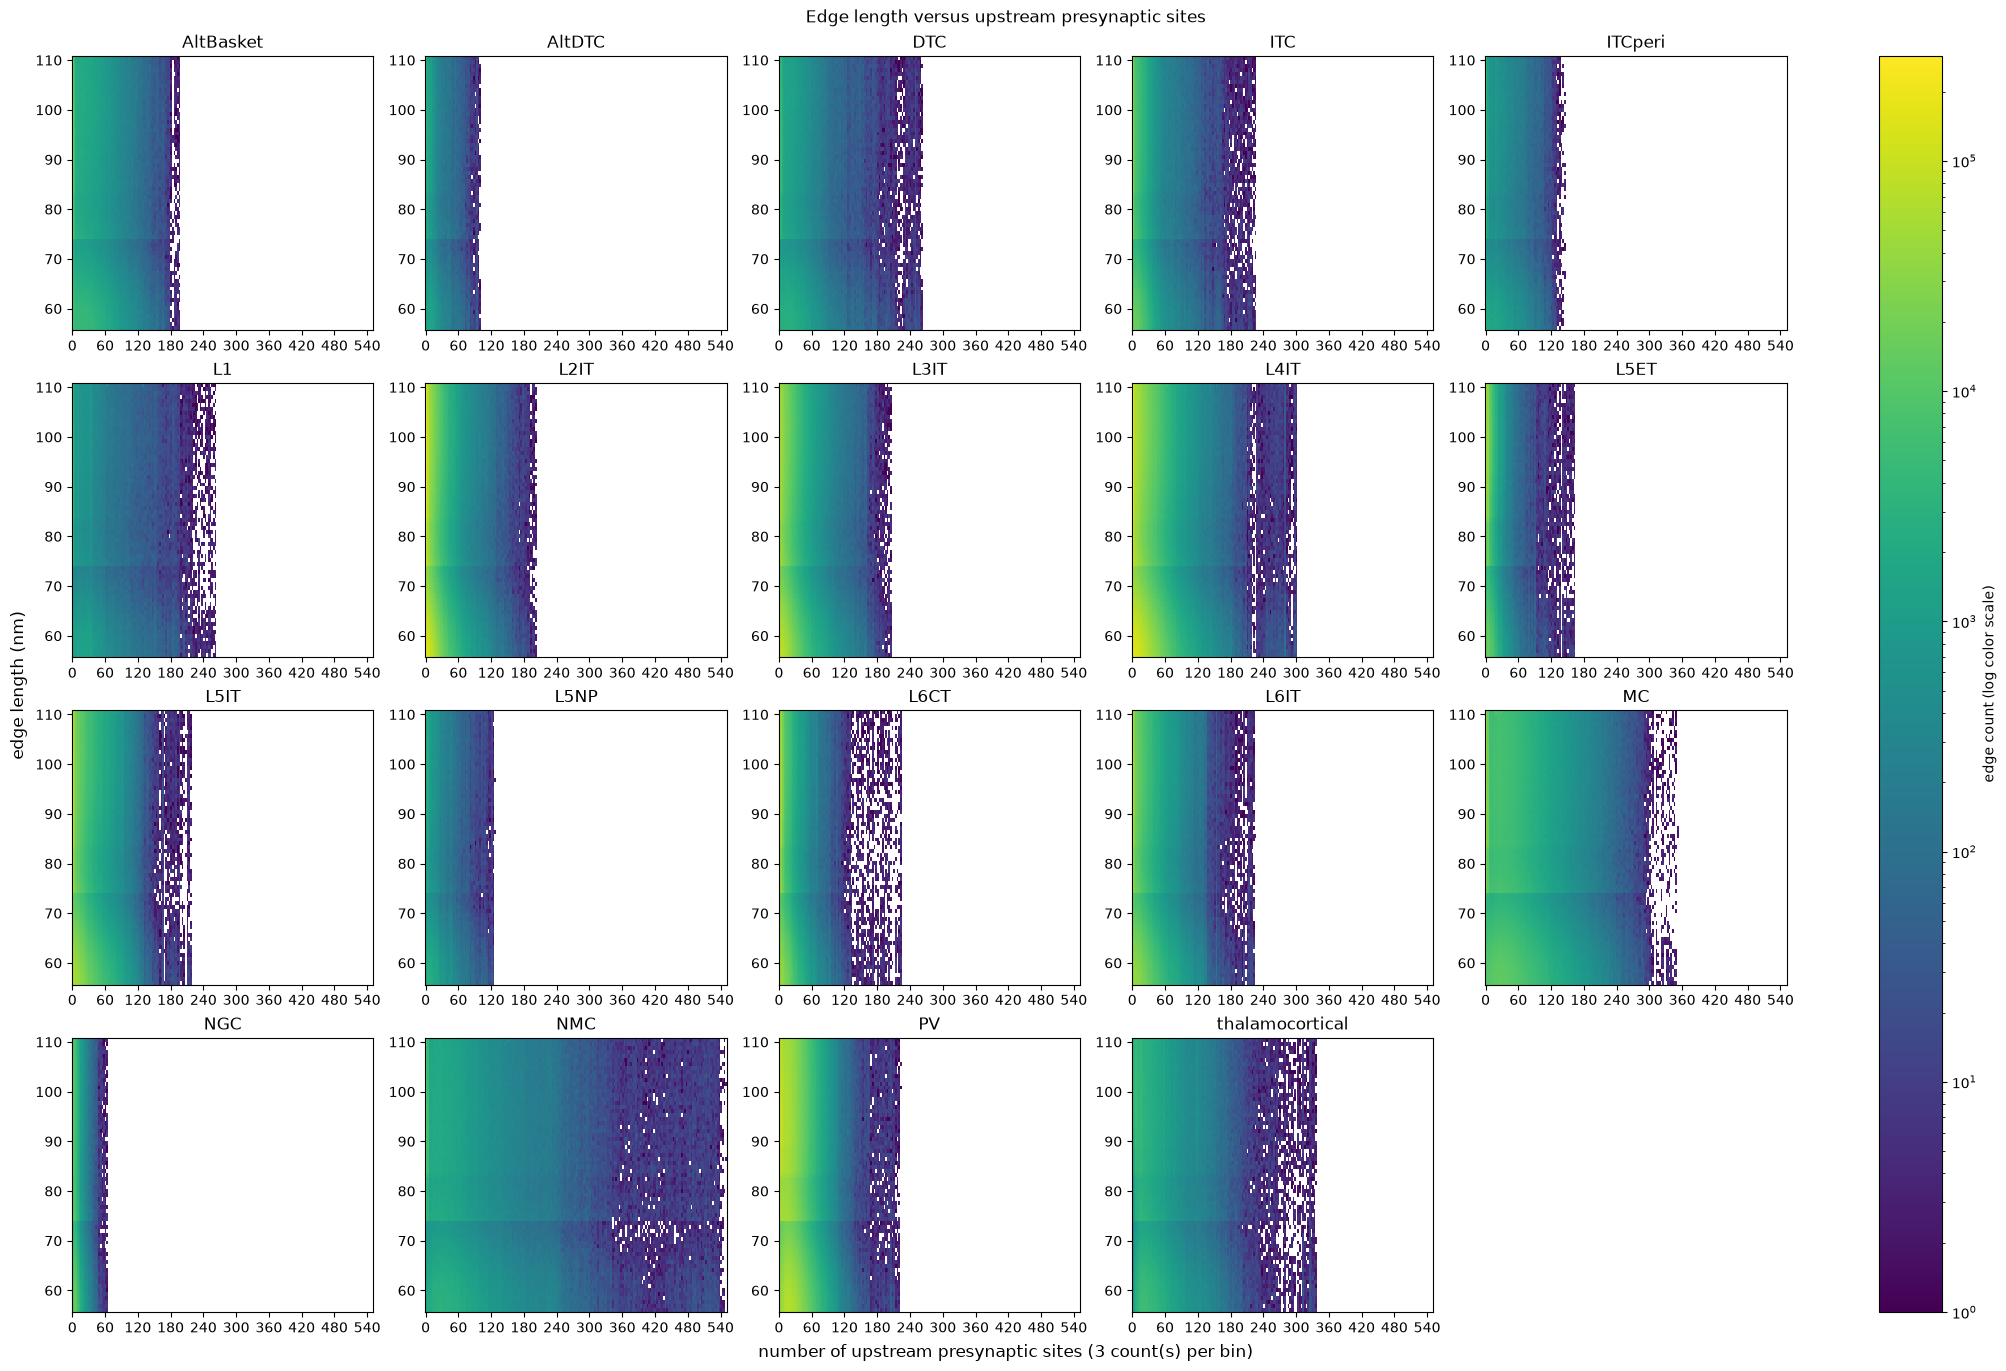

In [11]:
upstream_synapse_cell_type_figure = skeleton_stats.plot_edge_length_by_upstream_count(
    upstream_length_data, metric="synapses", by_cell_type=True
)
plt.close(upstream_synapse_cell_type_figure)  # Display once via the final expression.
upstream_synapse_cell_type_figure


## Presynaptic sites per connected component — before the >5 filter

Here **component means an undirected connected component after the 5 µm soma
cut**, including isolated nodes. This cutoff-diagnostic section deliberately
includes **all components, including zero-site components**, before either the
>5-site filter or upstream root/tree exclusions. It does not change the filter
used by the preceding analyses.

Count distinct presynaptic IDs mapped within 2 µm, using each dataset's existing
mapping: non-native to a mapped SegCLR-bearing node, native directly to a
resampled node. Components are counted once each and pooled across the same
2,209 cells. The histograms cover the complete range, including zero-site components,
using equal-width 100-site bins and linear axes. Heights are component counts
per bin. Change HISTOGRAM_BIN_WIDTH in the cell to adjust the bin width; the
range always extends through the maximum observed count. The retention curves apply **strictly >k sites**.

Loading cached connected-component site counts


,cells,components,zero_site_components,one_to_five_components,components_gt5,median_sites,p90_sites,p99_sites,max_sites
dataset,,,,,,,,,
Non-native,2209,16657,4402,6816,5439,2.0,280.0,3352.40,14557
Native resampled,2209,16765,3682,7253,5830,3.0,284.6,3413.96,14999


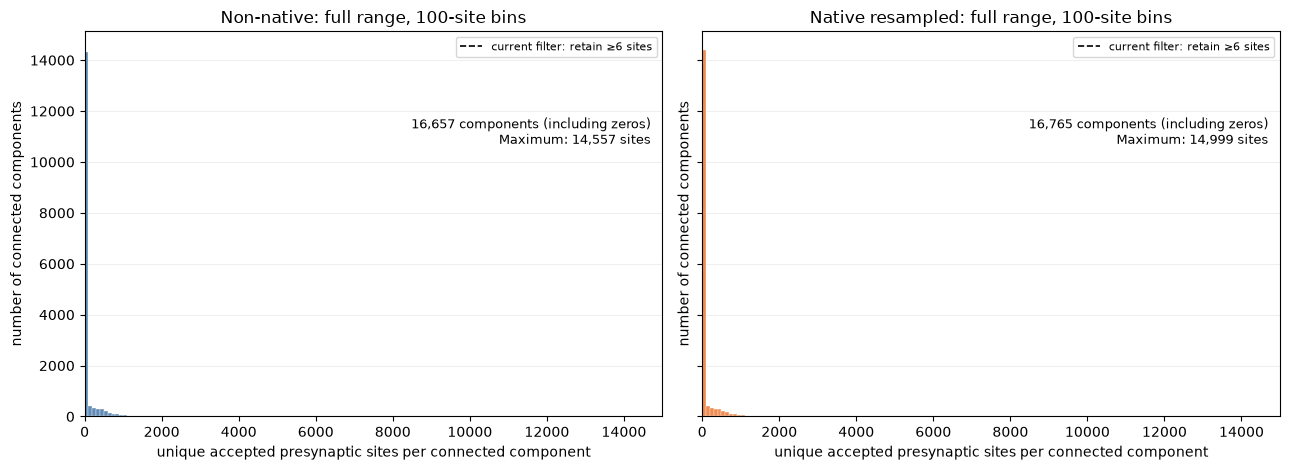

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'gnn').is_dir())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from analysis.presynaptic.component_site_distribution import component_site_counts
component_counts = component_site_counts.load_components()
display(component_site_counts.summary_table(component_counts))
HISTOGRAM_BIN_WIDTH = 100
component_distribution_figure = component_site_counts.plot_distribution(
    component_counts, bin_width=HISTOGRAM_BIN_WIDTH
)
plt.close(component_distribution_figure)
component_distribution_figure

,dataset,cutoff,retained_components,retained_component_fraction,retained_edges,retained_edge_fraction
0,Non-native,0,12255,0.7357,147521622,0.9840
1,Non-native,1,9819,0.5895,144509974,0.9639
2,Non-native,2,8038,0.4826,141758380,0.9455
3,Non-native,5,5439,0.3265,136241017,0.9087
4,Non-native,10,4107,0.2466,131862959,0.8795
5,Non-native,20,3458,0.2076,129039398,0.8607
6,Non-native,50,2759,0.1656,125373757,0.8362
7,Non-native,100,2328,0.1398,121589156,0.8110
8,Non-native,200,1924,0.1155,114843892,0.7660
9,Non-native,500,1013,0.0608,80797720,0.5389


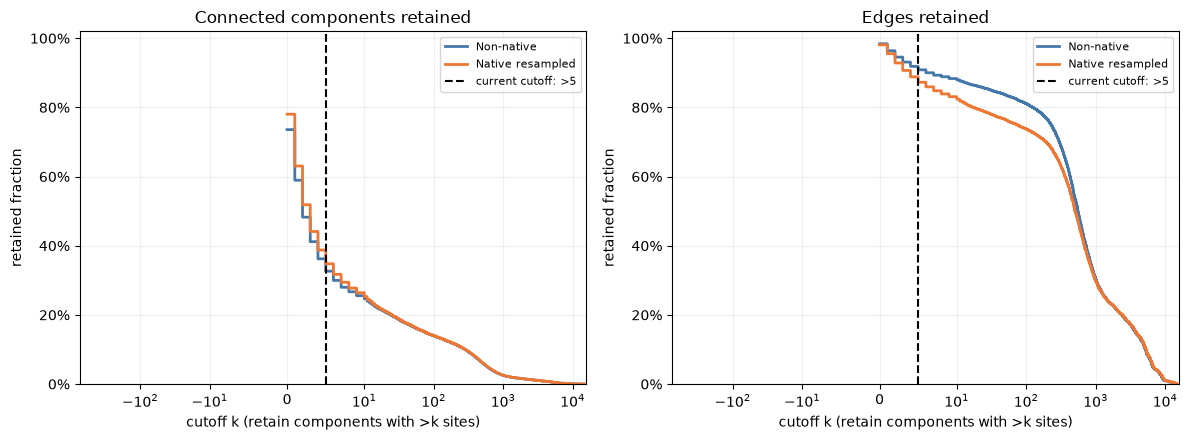

In [2]:
display(component_site_counts.cutoff_table(component_counts).round(4))
component_retention_figure = component_site_counts.plot_cutoff_retention(component_counts)
plt.close(component_retention_figure)
component_retention_figure